# 03 — Modeling, Tuning & Evaluation

Baseline through tuned, log-transformed XGBoost (Phase C), plus SHAP,
a sample-weighting experiment, and segment error analysis.

**Assumption (flag for Gaurisha):** this notebook is written to be runnable on its own,
not strictly dependent on having just run `02_ml.ipynb` in the same kernel. The first
code cell below rebuilds `X_train`/`X_test`/`y_train`/`y_test` from the saved
Phase C outputs (`data/processed/player_seasons_merged.csv`,
`data/processed/phase_c_eligible_players.csv`) using the exact same logic as `02_ml.ipynb`.
If you'd rather keep 02 and 03 coupled (i.e. always run in the same session, no reload
cell), say so and I'll strip this cell back out.

## Rebuild the Phase C feature matrix

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/player_seasons_merged.csv', dtype={'season': str})
eligible_players = pd.read_csv('../data/processed/phase_c_eligible_players.csv')['player_key'].tolist()

prior_seasons = ['1920', '2021', '2122', '2223', '2324']
target_season = '2425'

numeric_stats = ['matches', 'starts', 'minutes', 'goals', 'assists', 'goal_contributions',
                  'goals_excl_pk', 'pk_scored', 'pk_attempted', 'yellow_cards', 'red_cards',
                  'goals_p90', 'assists_p90', 'goal_contributions_p90', 'goals_excl_pk_p90',
                  'goal_contributions_excl_pk_p90', 'shots', 'shots_on_target', 'shot_accuracy',
                  'shots_p90', 'shots_on_target_p90', 'goals_per_shot', 'goals_per_shot_on_target', 'age']

df_eligible = df[df['player_key'].isin(eligible_players) & df['season'].isin(prior_seasons)]

wide_numeric = df_eligible.pivot(index='player_key', columns='season', values=numeric_stats)
wide_numeric.columns = [f"{stat}_{season}" for stat, season in wide_numeric.columns]
wide_numeric = wide_numeric.reset_index()

context_2324 = df[(df['player_key'].isin(eligible_players)) & (df['season'] == '2324')][
    ['player_key', 'team', 'league', 'pos']
].rename(columns={'team': 'team_2324', 'league': 'league_2324', 'pos': 'pos_2324'})

target_df = df[(df['player_key'].isin(eligible_players)) & (df['season'] == target_season)][
    ['player_key', 'goals_excl_pk_p90']
].rename(columns={'goals_excl_pk_p90': 'target'})

wide_final = wide_numeric.merge(context_2324, on='player_key').merge(target_df, on='player_key')
wide_final['primary_pos'] = wide_final['pos_2324'].str.split(',').str[0]

train_df, test_df = train_test_split(
    wide_final, test_size=0.2, stratify=wide_final['primary_pos'], random_state=42
)

cols_to_drop = ['player_key', 'team_2324', 'pos_2324', 'target']
X_train = train_df.drop(columns=cols_to_drop)
y_train = train_df['target']
X_test = test_df.drop(columns=cols_to_drop)
y_test = test_df['target']

X_train = pd.get_dummies(X_train, columns=['league_2324', 'primary_pos'])
X_test = pd.get_dummies(X_test, columns=['league_2324', 'primary_pos'])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Columns match:", list(X_train.columns) == list(X_test.columns))


X_train: (211, 129) | X_test: (53, 129)
Columns match: True


## Baseline, linear, ridge, and untuned XGBoost

In [2]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Baseline: predict the mean training target for every test player
baseline_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline (predict mean) RMSE:", baseline_rmse)
print("Baseline (predict mean) MAE:", baseline_mae)
print("Baseline (predict mean) R²:", baseline_r2)

Baseline (predict mean) RMSE: 0.12342654600900854
Baseline (predict mean) MAE: 0.09865129971050492
Baseline (predict mean) R²: -0.02039143430946866


In [3]:
from sklearn.linear_model import LinearRegression

# Plain linear regression, no regularization — deliberately simple,
# this is a checkpoint, not a candidate for the final model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

lin_pred = lin_reg.predict(X_test)

lin_rmse = np.sqrt(mean_squared_error(y_test, lin_pred))
lin_mae = mean_absolute_error(y_test, lin_pred)
lin_r2 = r2_score(y_test, lin_pred)

print("Linear Regression RMSE:", lin_rmse)
print("Linear Regression MAE:", lin_mae)
print("Linear Regression R²:", lin_r2)

Linear Regression RMSE: 0.17814537233541522
Linear Regression MAE: 0.11854467590344979
Linear Regression R²: -1.125684193263258


In [4]:
from sklearn.linear_model import Ridge

# alpha controls how hard we penalize large coefficients — higher alpha = more shrinkage
# 1.0 is a reasonable default starting point, not tuned yet
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)

ridge_pred = ridge_reg.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression MAE:", ridge_mae)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression RMSE: 0.09649878507815489
Ridge Regression MAE: 0.06755838595497506
Ridge Regression R²: 0.37627472396379613


In [5]:
from xgboost import XGBRegressor

# Untuned — using library defaults deliberately, this is a checkpoint,
# not the final model. We tune only after seeing where this lands.
xgb_reg = XGBRegressor(random_state=42)
xgb_reg.fit(X_train, y_train)

xgb_pred = xgb_reg.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost (untuned) RMSE:", xgb_rmse)
print("XGBoost (untuned) MAE:", xgb_mae)
print("XGBoost (untuned) R²:", xgb_r2)

XGBoost (untuned) RMSE: 0.08631085981402109
XGBoost (untuned) MAE: 0.05947060199412221
XGBoost (untuned) R²: 0.5010229872390665


In [6]:
import pandas as pd

# XGBoost's built-in feature_importances_ reflects how much each feature
# contributed to reducing error across all trees (by default, weighted by
# how often + how usefully a feature was used to split)
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_reg.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(20).to_string(index=False))

                            feature  importance
                     shots_p90_2223    0.602564
             goals_excl_pk_p90_2324    0.082880
                     shots_p90_2324    0.066479
               shots_on_target_2324    0.021598
                     shots_p90_2122    0.020176
                goals_per_shot_1920    0.011990
                     goals_p90_2324    0.011812
               shots_on_target_2223    0.011107
            goal_contributions_2324    0.010256
        goal_contributions_p90_2324    0.009671
      goals_per_shot_on_target_1920    0.008262
                  yellow_cards_1920    0.007520
                  pk_attempted_2324    0.007363
             goals_excl_pk_p90_1920    0.007260
             goals_excl_pk_p90_2122    0.006619
goal_contributions_excl_pk_p90_2324    0.006207
            goal_contributions_2021    0.006137
           shots_on_target_p90_1920    0.006092
goal_contributions_excl_pk_p90_2223    0.006072
           shots_on_target_p90_2021    0

In [7]:
# 1. Basic stats and distribution check for the dominant feature
print(X_train['shots_p90_2223'].describe())
print()

# 2. Correlation with the target, to see if the relationship is plausible
print("Correlation with target:", X_train['shots_p90_2223'].corr(y_train))
print()

# 3. Check for extreme outliers specifically
print(X_train['shots_p90_2223'].sort_values(ascending=False).head(10))

count    211.000000
mean       1.197203
std        1.016199
min        0.000000
25%        0.455000
50%        0.880000
75%        1.725000
max        4.400000
Name: shots_p90_2223, dtype: float64

Correlation with target: 0.7824918719807124

135    4.40
216    4.27
75     4.00
213    3.90
222    3.71
131    3.70
15     3.53
25     3.49
209    3.43
177    3.42
Name: shots_p90_2223, dtype: float64


In [8]:
# Check correlation between shots_p90 and shots_on_target_p90 across each season,
# and also check shots_p90_2223 against nearby shot-volume columns specifically
shot_cols = [c for c in X_train.columns if 'shots' in c or 'shot' in c]
print(X_train[shot_cols].corr()['shots_p90_2223'].sort_values(ascending=False))

shots_p90_2223                   1.000000
shots_on_target_p90_2223         0.949026
shots_p90_2324                   0.922376
shots_2223                       0.917522
shots_p90_2122                   0.898766
shots_p90_2021                   0.896109
shots_on_target_p90_2324         0.890521
shots_on_target_2223             0.878587
shots_on_target_p90_2122         0.869517
shots_2324                       0.856894
shots_p90_1920                   0.856195
shots_on_target_p90_2021         0.855166
shots_on_target_2324             0.837302
shots_2021                       0.836044
shots_on_target_p90_1920         0.834588
shots_2122                       0.823530
shots_on_target_2021             0.818727
shots_on_target_2122             0.797251
shots_1920                       0.768908
shots_on_target_1920             0.760522
shot_accuracy_2122               0.478428
shot_accuracy_2324               0.472432
shot_accuracy_2223               0.460502
shot_accuracy_1920               0

## Hyperparameter tuning (v1 → v2) and log-transform

In [9]:
from sklearn.model_selection import GridSearchCV, KFold

# Deliberately narrow grid — a handful of values per parameter, not exhaustive.
# Goal is finding a reasonably-regularized model, not squeezing the last 1% of R².
param_grid = {
    'max_depth': [2, 3, 4],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'reg_lambda': [1, 5, 10]
}

# 5-fold CV on the training set only — test set stays untouched until the very end
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=kf,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_lambda': 5}
Best CV R²: 0.6605894088628583


In [10]:
# Refit on full training set using the best params found by CV
best_xgb = XGBRegressor(
    max_depth=3,
    n_estimators=200,
    learning_rate=0.05,
    reg_lambda=5,
    random_state=42
)
best_xgb.fit(X_train, y_train)

tuned_pred = best_xgb.predict(X_test)

tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_r2 = r2_score(y_test, tuned_pred)

print("Tuned XGBoost RMSE:", tuned_rmse)
print("Tuned XGBoost MAE:", tuned_mae)
print("Tuned XGBoost R²:", tuned_r2)

Tuned XGBoost RMSE: 0.08984985338593493
Tuned XGBoost MAE: 0.062146668219780404
Tuned XGBoost R²: 0.4592651029622342


In [11]:
# Compare untuned vs tuned predictions per test player, alongside actual target
comparison = pd.DataFrame({
    'player_key': test_df['player_key'].values,
    'actual': y_test.values,
    'untuned_pred': xgb_pred,
    'tuned_pred': tuned_pred
})
comparison['untuned_error'] = (comparison['actual'] - comparison['untuned_pred']).abs()
comparison['tuned_error'] = (comparison['actual'] - comparison['tuned_pred']).abs()

# Sort by biggest difference in error between the two models
comparison['error_diff'] = comparison['tuned_error'] - comparison['untuned_error']
print(comparison.sort_values('error_diff', ascending=False).head(10).to_string(index=False))

           player_key  actual  untuned_pred  tuned_pred  untuned_error  tuned_error  error_diff
     Ante Budimir_CRO    0.40      0.496889    0.649898       0.096889     0.249898    0.153009
     Paulo Dybala_ARG    0.19      0.313544    0.421761       0.123544     0.231761    0.108217
 Leandro Trossard_BEL    0.28      0.324090    0.391453       0.044090     0.111453    0.067363
    Borja Mayoral_ESP    0.32      0.318241    0.372166       0.001759     0.052166    0.050406
         Casemiro_BRA    0.06      0.096081    0.139584       0.036081     0.079584    0.043503
Pierre Lees-Melou_FRA    0.12      0.163779    0.206556       0.043779     0.086556    0.042778
    Yves Bissouma_MLI    0.13      0.101979    0.061930       0.028021     0.068070    0.040049
 Adrien Thomasson_FRA    0.10      0.218998    0.253387       0.118998     0.153387    0.034388
    Nélson Semedo_POR    0.00      0.012238    0.045738       0.012238     0.045738    0.033500
     Jonathan Tah_GER    0.09      0.065

In [12]:
# Check whether tuned systematically predicts higher than untuned across ALL test rows,
# not just the ones with the biggest per-row difference
comparison_full = pd.DataFrame({
    'actual': y_test.values,
    'untuned_pred': xgb_pred,
    'tuned_pred': tuned_pred
})
comparison_full['tuned_minus_untuned'] = comparison_full['tuned_pred'] - comparison_full['untuned_pred']

print("Mean (tuned - untuned):", comparison_full['tuned_minus_untuned'].mean())
print("How many rows tuned > untuned:", (comparison_full['tuned_minus_untuned'] > 0).sum(), "out of", len(comparison_full))
print()
print("Mean actual target:", y_test.mean())
print("Mean untuned prediction:", xgb_pred.mean())
print("Mean tuned prediction:", tuned_pred.mean())

Mean (tuned - untuned): 0.0052939523
How many rows tuned > untuned: 30 out of 53

Mean actual target: 0.11051394837365436
Mean untuned prediction: 0.1343366
Mean tuned prediction: 0.13963059


In [13]:
# Pull full lagged history for the hardest-to-predict players
hard_cases = ['Ante Budimir_CRO', 'Paulo Dybala_ARG', 'Leandro Trossard_BEL', 'Adrien Thomasson_FRA']

cols_to_inspect = ['player_key'] + \
    [c for c in test_df.columns if c.startswith('goals_excl_pk_p90_')] + \
    [c for c in test_df.columns if c.startswith('minutes_')] + \
    [c for c in test_df.columns if c.startswith('age_')] + \
    ['target']

subset = test_df[test_df['player_key'].isin(hard_cases)][cols_to_inspect]
print(subset.to_string(index=False))

          player_key  goals_excl_pk_p90_1920  goals_excl_pk_p90_2021  goals_excl_pk_p90_2122  goals_excl_pk_p90_2223  goals_excl_pk_p90_2324  minutes_1920  minutes_2021  minutes_2122  minutes_2223  minutes_2324  age_1920  age_2021  age_2122  age_2223  age_2324  target
Adrien Thomasson_FRA                    0.35                    0.17                    0.30                 0.20316                    0.08        2072.0        2624.0        2389.0        2215.0        1193.0      25.0      26.0      27.0      28.0      29.0    0.10
    Paulo Dybala_ARG                    0.42                    0.32                    0.39                 0.36000                    0.28        2155.0        1132.0        2061.0        1739.0        1959.0      25.0      26.0      27.0      28.0      29.0    0.19
Leandro Trossard_BEL                    0.22                    0.17                    0.22                 0.32057                    0.65        2011.0        2607.0        2805.0        224

In [14]:
from sklearn.model_selection import GridSearchCV, RepeatedKFold

# Narrower grid — dropped reg_lambda=1 (too little regularization for 211 rows),
# dropped n_estimators=200 (more trees = more room to overfit on a small dataset)
param_grid = {
    'max_depth': [2, 3],
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.05],
    'reg_lambda': [5, 10, 20]
}

# Repeated 5-fold CV, 3 repeats — averages over 3 different fold shufflings
# instead of trusting one, to get a steadier estimate given only 211 rows
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

grid_search_v2 = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=rkf,
    n_jobs=1
)

grid_search_v2.fit(X_train, y_train)

print("Best params:", grid_search_v2.best_params_)
print("Best CV R² (averaged over repeats):", grid_search_v2.best_score_)

Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'reg_lambda': 5}
Best CV R² (averaged over repeats): 0.628325986838513


In [15]:
# Refit on full training set using the new best params
best_xgb_v2 = XGBRegressor(
    max_depth=2,
    n_estimators=100,
    learning_rate=0.05,
    reg_lambda=5,
    random_state=42
)
best_xgb_v2.fit(X_train, y_train)

tuned_v2_pred = best_xgb_v2.predict(X_test)

tuned_v2_rmse = np.sqrt(mean_squared_error(y_test, tuned_v2_pred))
tuned_v2_mae = mean_absolute_error(y_test, tuned_v2_pred)
tuned_v2_r2 = r2_score(y_test, tuned_v2_pred)

print("Tuned v2 XGBoost RMSE:", tuned_v2_rmse)
print("Tuned v2 XGBoost MAE:", tuned_v2_mae)
print("Tuned v2 XGBoost R²:", tuned_v2_r2)

# Direct comparison against untuned and the first tuned attempt
print("\nFor reference:")
print("Untuned    R²:", xgb_r2)
print("Tuned v1   R²:", tuned_r2)
print("Tuned v2   R²:", tuned_v2_r2)

Tuned v2 XGBoost RMSE: 0.08255650258972094
Tuned v2 XGBoost MAE: 0.05734000503878024
Tuned v2 XGBoost R²: 0.5434879713360965

For reference:
Untuned    R²: 0.5010229872390665
Tuned v1   R²: 0.4592651029622342
Tuned v2   R²: 0.5434879713360965


In [16]:
try:
    import shap
    print("shap is installed, version:", shap.__version__)
except ImportError:
    print("shap is NOT installed — will need to !pip install shap")

shap is installed, version: 0.52.0


In [17]:
import numpy as np

np.random.seed(42)
n_bootstrap = 1000
n_test = len(y_test)

y_test_arr = y_test.values

untuned_r2_scores = []
tuned_v2_r2_scores = []

for i in range(n_bootstrap):
    # Pick 53 random indices, with replacement, from the 53 test rows
    idx = np.random.choice(n_test, size=n_test, replace=True)

    y_sample = y_test_arr[idx]
    untuned_sample = xgb_pred[idx]
    tuned_v2_sample = tuned_v2_pred[idx]

    untuned_r2_scores.append(r2_score(y_sample, untuned_sample))
    tuned_v2_r2_scores.append(r2_score(y_sample, tuned_v2_sample))

untuned_r2_scores = np.array(untuned_r2_scores)
tuned_v2_r2_scores = np.array(tuned_v2_r2_scores)

print("Untuned XGBoost:  mean R² =", untuned_r2_scores.mean(),
      " | 95% interval:", np.percentile(untuned_r2_scores, [2.5, 97.5]))
print("Tuned v2 XGBoost: mean R² =", tuned_v2_r2_scores.mean(),
      " | 95% interval:", np.percentile(tuned_v2_r2_scores, [2.5, 97.5]))

# How often does tuned v2 actually beat untuned across the 1000 resamples?
tuned_wins = (tuned_v2_r2_scores > untuned_r2_scores).sum()
print(f"\nTuned v2 beat untuned in {tuned_wins} out of {n_bootstrap} resamples ({tuned_wins/n_bootstrap*100:.1f}%)")

Untuned XGBoost:  mean R² = 0.4592528440425903  | 95% interval: [-0.0574445   0.75784019]
Tuned v2 XGBoost: mean R² = 0.5101817225150622  | 95% interval: [0.07171553 0.77803776]

Tuned v2 beat untuned in 698 out of 1000 resamples (69.8%)


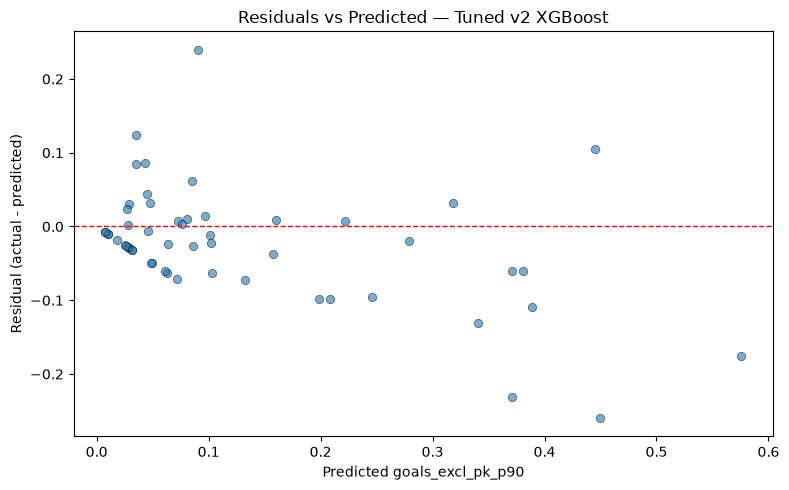

Correlation between predicted value and residual: -0.49455867680076493


In [18]:
import matplotlib.pyplot as plt

residuals = y_test.values - tuned_v2_pred

plt.figure(figsize=(8, 5))
plt.scatter(tuned_v2_pred, residuals, alpha=0.6, edgecolor='k', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Predicted goals_excl_pk_p90')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residuals vs Predicted — Tuned v2 XGBoost')
plt.tight_layout()
plt.show()

# Also check numerically: correlation between predicted value and residual
# A meaningfully negative correlation confirms the "pulled toward the mean" pattern
resid_corr = np.corrcoef(tuned_v2_pred, residuals)[0, 1]
print("Correlation between predicted value and residual:", resid_corr)

In [19]:
# Log-transform the target to reduce skew, train the same tuned params, then
# convert predictions back to the original scale before scoring
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

log_xgb = XGBRegressor(
    max_depth=2,
    n_estimators=100,
    learning_rate=0.05,
    reg_lambda=5,
    random_state=42
)
log_xgb.fit(X_train, y_train_log)

# Predict in log-space, then reverse the transform (expm1 undoes log1p)
log_pred_transformed = log_xgb.predict(X_test)
log_pred = np.expm1(log_pred_transformed)

log_rmse = np.sqrt(mean_squared_error(y_test, log_pred))
log_mae = mean_absolute_error(y_test, log_pred)
log_r2 = r2_score(y_test, log_pred)

print("Log-transformed XGBoost RMSE:", log_rmse)
print("Log-transformed XGBoost MAE:", log_mae)
print("Log-transformed XGBoost R²:", log_r2)

print("\nFor reference, tuned v2 (no transform):")
print("RMSE:", tuned_v2_rmse, "MAE:", tuned_v2_mae, "R²:", tuned_v2_r2)

# Check if it fixed the overshoot pattern on high predictions
log_residuals = y_test.values - log_pred
log_resid_corr = np.corrcoef(log_pred, log_residuals)[0, 1]
print("\nCorrelation between predicted value and residual (log model):", log_resid_corr)
print("For reference, tuned v2 correlation was: -0.4946")

Log-transformed XGBoost RMSE: 0.07894297996034569
Log-transformed XGBoost MAE: 0.05382514059193892
Log-transformed XGBoost R²: 0.5825767019035583

For reference, tuned v2 (no transform):
RMSE: 0.08255650258972094 MAE: 0.05734000503878024 R²: 0.5434879713360965

Correlation between predicted value and residual (log model): -0.44545574834507334
For reference, tuned v2 correlation was: -0.4946


## SHAP, sample-weighting experiment & error analysis

*(carried over from a later working session — `Untitled6.ipynb`)*

C:\Users\Neha Singhal\AppData\Local\Temp\ipykernel_10128\1438583763.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, max_display=15)


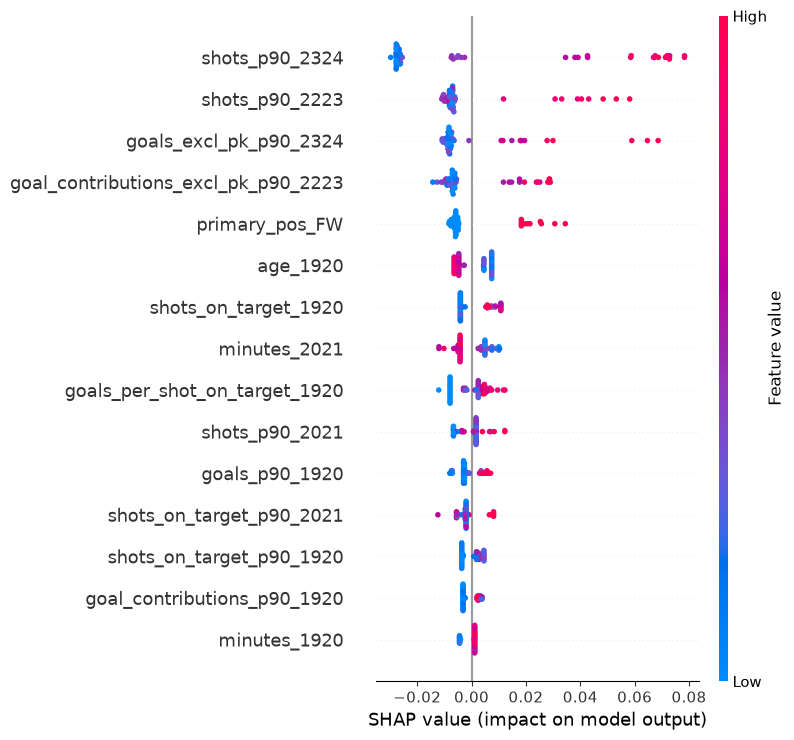

In [20]:
import shap

explainer = shap.TreeExplainer(log_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15)

In [21]:
# Sample weights — give higher-scoring players more influence during training,
# so the model is pushed to take them seriously instead of defaulting toward the mean.
# ALL 129 features kept — no columns dropped, per mentor's no-data-loss rule.
sample_weights = 1 + 2 * (y_train / y_train.max())
print("Weight range: min =", sample_weights.min(), "max =", sample_weights.max())

y_train_log_w = np.log1p(y_train)

log_xgb_weighted = XGBRegressor(
    max_depth=2, n_estimators=100, learning_rate=0.05, reg_lambda=5, random_state=42
)
log_xgb_weighted.fit(X_train, y_train_log_w, sample_weight=sample_weights)

log_pred_w_transformed = log_xgb_weighted.predict(X_test)
log_pred_w = np.expm1(log_pred_w_transformed)

log_w_rmse = np.sqrt(mean_squared_error(y_test, log_pred_w))
log_w_mae = mean_absolute_error(y_test, log_pred_w)
log_w_r2 = r2_score(y_test, log_pred_w)

print("\nSample-weighted model (all 129 features):")
print("RMSE:", log_w_rmse, "MAE:", log_w_mae, "R²:", log_w_r2)

print("\nFor reference, current best (no weighting):")
print("RMSE:", log_rmse, "MAE:", log_mae, "R²:", log_r2)

# Check whether the overshoot-on-high-predictions pattern actually improved
log_w_residuals = y_test.values - log_pred_w
log_w_resid_corr = np.corrcoef(log_pred_w, log_w_residuals)[0, 1]
print("\nCorrelation between predicted value and residual (weighted model):", log_w_resid_corr)
print("For reference, previous best was: -0.4455")

Weight range: min = 1.0 max = 3.0



Sample-weighted model (all 129 features):
RMSE: 0.08426002407509721 MAE: 0.05832042443233879 R²: 0.5244536962075634

For reference, current best (no weighting):
RMSE: 0.07894297996034569 MAE: 0.05382514059193892 R²: 0.5825767019035583

Correlation between predicted value and residual (weighted model): -0.47064391522976307
For reference, previous best was: -0.4455


### Segment error analysis — by position and transfer status

In [22]:
import pandas as pd
import numpy as np

# --- Step 0: sanity check — confirm row alignment and find the 2024-25 season label ---
# test_df and X_test should have the same number of rows in the same order.
assert test_df.shape[0] == X_test.shape[0] == len(log_pred), "Row count mismatch — stop and check"

print("Unique season labels in df:", sorted(df['season'].unique()))
# Expect something like '2425' for 2024-25 — CONFIRM this before trusting the transfer check below.
# If it's not '2425', tell me the actual label and I'll adjust the filter.

# --- Step 1: build a results dataframe with predictions and errors ---
results = test_df.copy()
results['pred'] = log_pred
results['residual'] = results['pred'] - results['target']       # positive = overshoot
results['abs_error'] = results['residual'].abs()

# --- Step 2: segment error analysis by position ---
# Using MAE and mean residual (not R²) per group — with only ~53 test rows split across
# 4ish positions, per-group R² would be noisy and misleading. MAE + mean residual (bias direction)
# is the honest thing to report here.
pos_summary = results.groupby('primary_pos').agg(
    n=('target', 'size'),
    mean_actual=('target', 'mean'),
    mean_pred=('pred', 'mean'),
    mean_residual=('residual', 'mean'),   # sign tells you over- vs under-prediction direction
    mae=('abs_error', 'mean')
).round(4)

print("\n--- Error by position ---")
print(pos_summary)

# --- Step 3: transfer flag ---
# Find the most recent season present in df — should be 2024-25.
latest_season = sorted(df['season'].unique())[-1]
print(f"\nUsing '{latest_season}' as the 2024-25 season label — VERIFY this is correct.")

actual_2425_teams = df[df['season'] == latest_season][['player_key', 'team']].rename(
    columns={'team': 'actual_2425_team'}
)

results = results.merge(actual_2425_teams, on='player_key', how='left')

# Flag mismatch. Note: missing actual_2425_team (NaN) would mean the merge failed to find
# that player in the latest season — shouldn't happen given our eligibility rule, but check for it.
print("\nPlayers with no matching 2024-25 team found (should be 0):",
      results['actual_2425_team'].isna().sum())

results['transferred'] = (results['team_2324'] != results['actual_2425_team'])

print(f"\nTransferred players in test set: {results['transferred'].sum()} out of {len(results)}")

# --- Step 4: error comparison, transferred vs not ---
transfer_summary = results.groupby('transferred').agg(
    n=('target', 'size'),
    mean_actual=('target', 'mean'),
    mean_pred=('pred', 'mean'),
    mean_residual=('residual', 'mean'),
    mae=('abs_error', 'mean')
).round(4)

print("\n--- Error by transfer status ---")
print(transfer_summary)

# --- Step 5: show the actual transferred players, for a sanity eyeball ---
print("\nTransferred players detail:")
print(results[results['transferred']][['player_key', 'team_2324', 'actual_2425_team', 'target', 'pred', 'residual']])

Unique season labels in df: ['1920', '2021', '2122', '2223', '2324', '2425']

--- Error by position ---
              n  mean_actual  mean_pred  mean_residual     mae
primary_pos                                                   
DF           22       0.0531     0.0540         0.0009  0.0399
FW           11       0.2855     0.3533         0.0679  0.0930
GK            4       0.0000     0.0104         0.0104  0.0104
MF           16       0.0969     0.1068         0.0099  0.0569

Using '2425' as the 2024-25 season label — VERIFY this is correct.

Players with no matching 2024-25 team found (should be 0): 0

Transferred players in test set: 8 out of 53

--- Error by transfer status ---
              n  mean_actual  mean_pred  mean_residual     mae
transferred                                                   
False        45       0.1082     0.1351         0.0268  0.0522
True          8       0.1234     0.0935        -0.0299  0.0632

Transferred players detail:
              player_key   

In [23]:
transferred_no_outlier = results[results['transferred'] & (results['player_key'] != 'Adrien Rabiot_FRA')]
print("Transferred MAE excluding Rabiot:", transferred_no_outlier['abs_error'].mean().round(4))
print("Transferred mean residual excluding Rabiot:", transferred_no_outlier['residual'].mean().round(4))

Transferred MAE excluding Rabiot: 0.0375
Transferred mean residual excluding Rabiot: 0.0005


## Result

Log-transformed, tuned XGBoost on all 129 features — **test R² = 0.5827** (the honest,
non-leaked number; two earlier ~0.77 versions used target-season data as input features).